An organization sends promotional emails. Historical data indicate that a customer 
clicks the link with probability 
P(c) = 0.3

the set of x=[0,1]

What does x = 1 represent?          p(c) 
what does x = 0 represent?          p(c')
What are the possible values of X ?              x=[0,1]
Is a discrete or continuous random variable?      It's a descrite Random Variable
Which probability distribution is suitable for ?     Bernoulli's Probability Distribution

PMF(x=0):  p(c') =0.7
PMF(x=1): p(c) = 0.3

In [57]:
import numpy as np

p = 0.3
sample_size = 20
samples = np.random.binomial(n=1,p=p, size=sample_size)

print(samples)

[0 0 1 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0]


 How many observations were generated?   20 Obseavtions
What does each zero represent?      0 represents a non-click — the customer did not click the advertisement.
What does each one represent?       1 represents a click — the customer clicked the advertisement.
are you represents a click — the customer clicked the advertisement.

In [58]:
number_of_clicks = np.sum(samples == 1)
number_of_non_clicks = np.sum(samples == 0)

print("Number of clicks:", number_of_clicks)
print("Number of non-clicks:", number_of_non_clicks)

Number of clicks: 8
Number of non-clicks: 12


 How many customers clicked?              6 customers
 How many customers did not click?        14 customers
 Do the two counts add up to 20?          Yes, The total is 20

In [59]:
empirical_pmf={
    0: number_of_non_clicks/sample_size,
    1: number_of_clicks/sample_size
}
print(empirical_pmf)

{0: np.float64(0.6), 1: np.float64(0.4)}


In [60]:
theoretical_pmf = {
    0: 1 - p,
    1: p
}
theoretical_pmf

{0: 0.7, 1: 0.3}

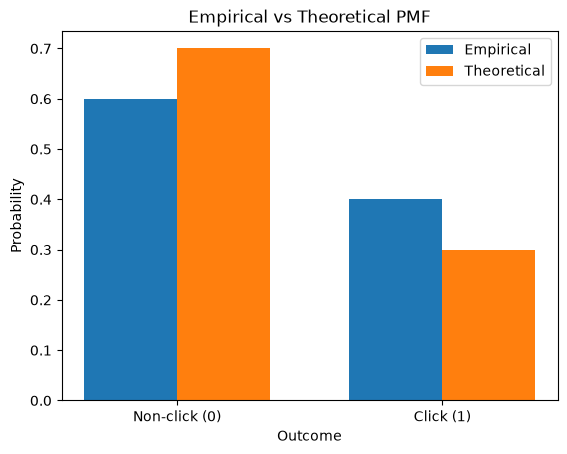

In [61]:
import matplotlib.pyplot as plt

x = [0, 1]

empirical = [
    empirical_pmf[0],
    empirical_pmf[1]
]

theoretical = [
    theoretical_pmf[0],
    theoretical_pmf[1]
]

width = 0.35

plt.bar(np.array(x) - width/2, empirical, width, label="Empirical")
plt.bar(np.array(x) + width/2, theoretical, width, label="Theoretical")

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Empirical vs Theoretical PMF")
plt.xticks(x, ["Non-click (0)", "Click (1)"])
plt.legend()
plt.show()

Theoretical Expectation and Emperical expectation

In [64]:
theoretical_mean = p
print(f"theoretical_mean: {theoretical_mean}")

theoretical_mean: 0.3


In [65]:
emperical_mean = np.mean(samples)
print(f"emperical_mean: {emperical_mean}")

emperical_mean: 0.4


Theoretical Variance and Emperical Variance

In [66]:
theoretical_var = p  * (1-p)
print(f"theoretical_var: {theoretical_var}")

theoretical_var: 0.21


In [67]:
emperical_var = np.var(samples)
print(f"emperical_var: {emperical_var}")

emperical_var: 0.24000000000000005


In [68]:
sample_sizes = [10, 100, 1000, 10000]

print("Sample Size\tEmpirical Mean\tEmpirical Variance")

for sample_size in sample_sizes:
    samples = np.random.binomial(
        n=1,
        p=p,
        size=sample_size
    )

    empirical_mean = np.mean(samples)
    empirical_variance = np.var(samples)

    print(
        sample_size,
        "\t\t",
        empirical_mean,
        "\t\t",
        empirical_variance
    )

Sample Size	Empirical Mean	Empirical Variance
10 		 0.3 		 0.20999999999999996
100 		 0.27 		 0.19710000000000005
1000 		 0.304 		 0.211584
10000 		 0.2905 		 0.20610974999999998


Problem Set 2: ML Use Case: Number of Fraudulent Transactions Flagged
Problem statement: A fraud-detection model examines 50 transactions every 
hour. Assume that each transaction has a 4% probability of being flagged as 
potentially fraudulent.
Let:
Initially assume that individual flagging decisions are independent.
The fraud investigation team can examine at most four flagged transactions per 
hour.
Find:
1: Simulate the operation of the fraud-detection system for 20,000 independent one-hour periods.
During every simulated hour:
 exactly 50 transactions are examined; 
 each transaction has a flagging probability of 0.04 
 records the total number of flagged transactions.
Hint: use np.random.binomial function



In [70]:
import numpy as np

p = 0.04
sample_size = 20000
samples = np.random.binomial(n=50,p=p, size=sample_size)

print(list(samples))

[np.int32(1), np.int32(0), np.int32(2), np.int32(3), np.int32(2), np.int32(3), np.int32(3), np.int32(3), np.int32(1), np.int32(4), np.int32(2), np.int32(1), np.int32(6), np.int32(4), np.int32(2), np.int32(3), np.int32(1), np.int32(2), np.int32(1), np.int32(2), np.int32(2), np.int32(1), np.int32(2), np.int32(0), np.int32(0), np.int32(1), np.int32(2), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(4), np.int32(1), np.int32(3), np.int32(1), np.int32(1), np.int32(1), np.int32(4), np.int32(2), np.int32(3), np.int32(2), np.int32(1), np.int32(4), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(2), np.int32(1), np.int32(2), np.int32(0), np.int32(5), np.int32(1), np.int32(2), np.int32(3), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(2), np.int32(2), np.int32(0), np.int32(4), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(3), np.int32(2), np.int32(5), np.int32(2)

In [71]:
emp_mean = np.mean(samples)
emp_var = np.var(samples)

the_mean = 50*p
the_var = 50  * p * (1-p)

print("emp_mean: ", emp_mean)
print("emp_var: ", emp_var)
print("the_mean: ", the_mean)
print("the_var: ", the_var)

emp_mean:  1.99255
emp_var:  1.9232944975
the_mean:  2.0
the_var:  1.92
